# Processing Inhibitor Data

____

In [24]:
from pathlib import Path
current_dir = Path().resolve()
from microlive.imports import *
from microlive import microscopy as mi
main_dir = Path().resolve().parent
one_drive_dir = mi.Utilities.get_one_drive_dir()
import inhibitors as INH

## Data Configuration
___

In [25]:
# Loading data
        #RMS External Drive Location:    'E:/Co-translational folding (CoF) paper/Har Analysis/Fig S3C_Har_Fits_4xFast without anti-GFP-IB'
        #Ning Zhao OneDrive Location:    '...General - Zhao (NZ) Lab/Zhao lab shared folder/Our papers/co-translational folding paper/Fig S3/S3C_Fast har_GFP-ib/Fast har_GFP-ib analysis'

data_dir = Path(r'E:/Co-translational folding (CoF) paper/Har Analysis/Fig S3C_Har_Fits_4xFast without anti-GFP-IB') 
 
# elongation rates
def elongation_rates (gene_length,dwell_time ):
    ke = gene_length/ dwell_time
    return np.round(ke,3)

# ── Processing Parameters ─────────────────────────────────
inhibitor_frame_index = 4  # 0-indexed: frame when treatment was applied
use_sem = True
show_summary = True
show_individual_trajectories = False
max_percentage_threshold_after_treatment = None #0.5
threshold_percentage_for_runoff = 0.1
use_sigmoidal_fit = True
# ── Plotting Parameters ───────────────────────────────────
figsize = (5, 4)
ylims = (-0.1, 1.3)
xlims = (-5, 41.5)                              # limits needs to be set to include more than the fit_end_idx frames for the x-axis
results_folder = Path('Fig S3C_Har')                   # Set to a Path to save plots or use Path('temp')
results_folder.mkdir(parents=True, exist_ok=True)


In [26]:
# parameters for linears fits 
r2_threshold = 0.95    # must match what you passed to plot_inhibitor
drug_diffusion_time_min = 1
frame_interval_sec = 60
# gene length
g_length = 1826  # gene length total
half_tag = 167   # gene length total
g_length_effective = g_length-half_tag # gene_length_without_half_tag

## HA Channel (pRS027 without LaG16; 4xGFPfast)
___

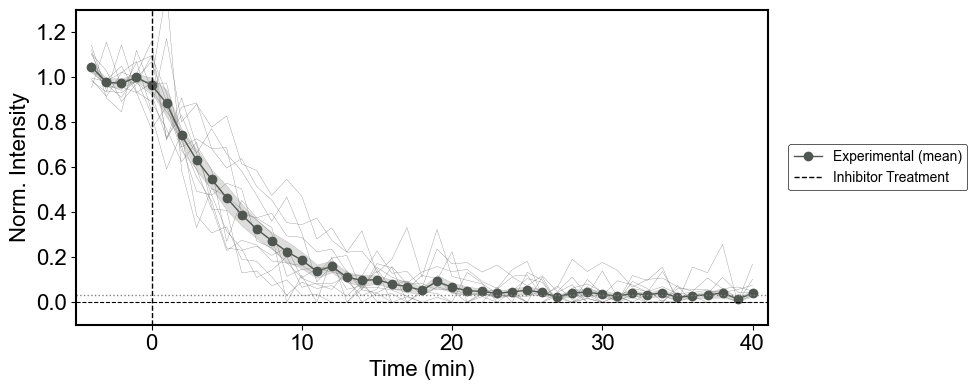

responding_indices_pRS027_pNZ055_HA: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
number of responding trajectories for pRS027_pNZ055_HA: 12


In [27]:
substring_in_data_dir = 'pRS027_pNZ055'
selected_field = 'spot_int_ch_0'
plot_name = 'pRS027_no LaG16_traces'
 
responding_indices_pRS027_pNZ055_HA, frames_pRS027_pNZ055_HA, intensities_pRS027_pNZ055_HA, _, _, _, _, _ = INH.process_inhibitor_data(
    data_dir, inhibitor_frame_index, substring_in_data_dir, selected_field,
    use_sem, show_summary, max_percentage_threshold_after_treatment,remove_frame_at_inhibitor_application=False,
)
 
 
INH.plot_inhibitor(
    frames_pRS027_pNZ055_HA,                                # np.ndarray – time array
    intensities_pRS027_pNZ055_HA,                           # np.ndarray – 2D (cells × frames)
    inhibitor_frame_index,                           # int – treatment frame index
    results_folder=results_folder,                   # Path – save location
    plot_name=plot_name,                             # str – filename suffix
    responding_indices=responding_indices_pRS027_pNZ055, # list – which cells to include
    use_sem=True,                                    # bool – SEM vs SD for error band
    show_individual_trajectories=True,               # bool – gray individual traces
    figsize = (8, 4),
    ylims = (-0.1, 1.3),
    xlims = (-5, 41),                          # limits needs to be set to include more than the fit_end_idx frames for the x-axis
    y_label='Norm. Intensity',                       # str
    treatment_label='Inhibitor',                     # str – label for treatment line
    show_treatment_line=True,                        # bool – vertical line at t=0
    #fit_model='None',                           # 'linear'|'exponential'|'heaviside'|None
    #fit_start_idx=fit_start_idx,                     # int – fit range start (default: inh frame)
    #fit_end_idx=fit_end_idx,                         # int – fit range end (default: last frame)
    #show_fit=False,                                   # bool – overlay fitted curve
    show_runoff_time=True,                           # bool – draw t½ and τ_runoff lines
    runoff_fraction=0.9,                            # float – threshold for run-off (0.95 = 95%)
    show_background_line=True,                      # dashed line at background level
    show_zero_y_axis=True,                          # dashed line at y = 0
    colors="#505750",
)
 
print("responding_indices_pRS027_pNZ055_HA:", responding_indices_pRS027_pNZ055_HA)
print("number of responding trajectories for pRS027_pNZ055_HA:", len(responding_indices_pRS027_pNZ055_HA))

## HA Channel (pRS027 with LaG16; 4xGFPfast)
___

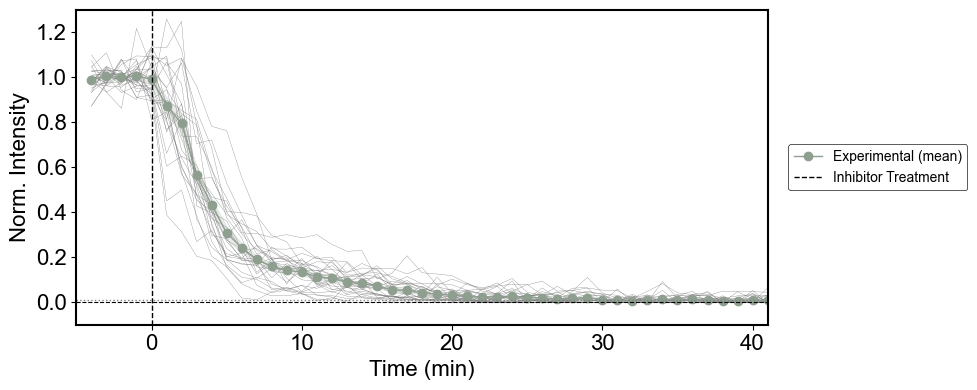

responding_indices_pRS027_HA: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
number of responding trajectories for pRS027_HA: 26


In [28]:
substring_in_data_dir = 'Har pRS027_Dish'
selected_field = 'spot_int_ch_0'
plot_name = 'pRS027-only_HA_fit'
 
responding_indices_pRS027_HA, frames_pRS027_HA, intensities_pRS027_HA, _, _, _, _, _ = INH.process_inhibitor_data(
    data_dir, inhibitor_frame_index, substring_in_data_dir, selected_field,
    use_sem, show_summary, max_percentage_threshold_after_treatment,remove_frame_at_inhibitor_application=False,frame_interval_sec = frame_interval_sec,
)
 
 
results=INH.plot_inhibitor(
    frames_pRS027_HA,                                 # np.ndarray – time array
    intensities_pRS027_HA,                            # np.ndarray – 2D (cells × frames)
    inhibitor_frame_index,                            # int – treatment frame index
    results_folder=results_folder,                    # Path – save location
    plot_name=plot_name,                              # str – filename suffix
    responding_indices=responding_indices_pRS027_HA,  # list – which cells to include
    figsize = (8, 4),
    ylims = (-0.1, 1.3),
    xlims = (-5, 41),                          # limits needs to be set to include more than the fit_end_idx frames for the x-axis
    y_label='Norm. Intensity',                       # str
    treatment_label='Inhibitor',                     # str – label for treatment line
    show_treatment_line=True,                        # bool – vertical line at t=0
    #fit_model='None',                           # 'linear'|'exponential'|'heaviside'|None
    #fit_start_idx=fit_start_idx,                     # int – fit range start (default: inh frame)
    #fit_end_idx=fit_end_idx,                         # int – fit range end (default: last frame)
    #show_fit=False,                                   # bool – overlay fitted curve
    show_runoff_time=True,                           # bool – draw t½ and τ_runoff lines
    runoff_fraction=0.9,                            # float – threshold for run-off (0.95 = 95%)
    show_background_line=True,                      # dashed line at background level
    show_zero_y_axis=True,                          # dashed line at y = 0
    colors="#8E9E8F",
)
 
print("responding_indices_pRS027_HA:", responding_indices_pRS027_HA)
print("number of responding trajectories for pRS027_HA:", len(responding_indices_pRS027_HA))
 
 
# Access each dataset by index
#print('run-off time dataset 0:', results['t_runoff'])

## Normalized Comparison Graphs

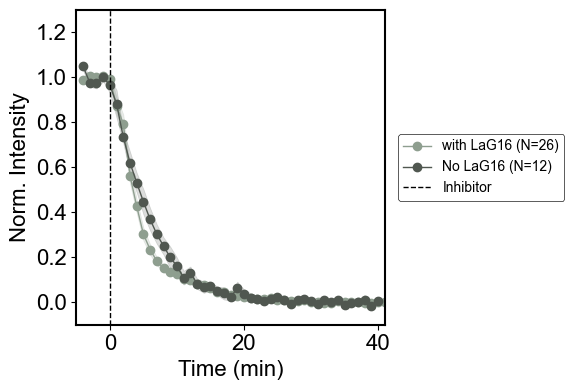

responding_indices_pRS027_HA: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
number of responding trajectories for pRS027_HA: 26
responding_indices_pRS027_pNZ055_HA: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
number of responding trajectories for pRS027_pNZ055_HA: 12


In [29]:
INH.plot_multiple_inhibitors(
    [frames_pRS027_HA, frames_pRS027_pNZ055_HA,],
    [intensities_pRS027_HA, intensities_pRS027_pNZ055_HA],
    inhibitor_frame_index,
    responding_indices_list=[responding_indices_pRS027_HA, responding_indices_pRS027_pNZ055_HA],
    colors=["#8E9E8F", "#505750"], 
    legend_labels=['with LaG16 (N=26)', 'No LaG16 (N=12)'],
    plot_name='LaG16 comparison_norm',
    #threshold_percentage_for_runoff=-0.4,
    ylims=ylims,
    xlims=(-5, 41),
    figsize=(6, 4),
    use_sem=True,
    show_individual_trajectories=show_individual_trajectories,
    show_treatment_line=True,                        # bool – vertical line at t=0
    show_runoff_time=False,                           # bool – draw t½ and τ_runoff lines
    remove_background_intensity=True,                 # subtract background & rescale to 0-1
    background_frames=10,                             # use last 10 frames within xlims window
    show_background_line=False,                        # dashed line at background level
    show_zero_y_axis=False,                            # dashed line at y = 0
    results_folder=results_folder,
)

print("responding_indices_pRS027_HA:", responding_indices_pRS027_HA)
print("number of responding trajectories for pRS027_HA:", len(responding_indices_pRS027_HA))
print("responding_indices_pRS027_pNZ055_HA:", responding_indices_pRS027_pNZ055_HA)
print("number of responding trajectories for pRS027_pNZ055_HA:", len(responding_indices_pRS027_pNZ055_HA))
